In [3]:

# ─────────────────────────────────────────────────────────────
# CIC-DDoS 2019  |  Memory-efficient loader + EDA + ML
# Dataset size: ~30 GB   Strategy: chunking + sampling
# ─────────────────────────────────────────────────────────────
import os, glob, gc, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────
BASE_DIR   = Path(r"d:\Khóa luận\Dataset")
CSV_DIRS   = [
    BASE_DIR / "CSV-01-12" / "01-12",
    BASE_DIR / "CSV-03-11" / "03-11",
]

# Collect all CSV files
all_csv = []
for d in CSV_DIRS:
    all_csv.extend(sorted(d.glob("*.csv")))

print(f"Total CSV files found: {len(all_csv)}")
for f in all_csv:
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:35s}  {size_mb:8.1f} MB")


Total CSV files found: 18
  DrDoS_DNS.csv                          2133.3 MB
  DrDoS_LDAP.csv                          917.3 MB
  DrDoS_MSSQL.csv                        1889.2 MB
  DrDoS_NetBIOS.csv                      1697.5 MB
  DrDoS_NTP.csv                           645.0 MB
  DrDoS_SNMP.csv                         2172.6 MB
  DrDoS_SSDP.csv                         1252.7 MB
  DrDoS_UDP.csv                          1506.0 MB
  Syn.csv                                 637.3 MB
  TFTP.csv                               9302.0 MB
  UDPLag.csv                              158.0 MB
  LDAP.csv                                871.4 MB
  MSSQL.csv                              2386.2 MB
  NetBIOS.csv                            1418.5 MB
  Portmap.csv                              78.6 MB
  Syn.csv                                1877.4 MB
  UDP.csv                                1792.8 MB
  UDPLag.csv                              319.8 MB


## 1. Memory-Efficient Data Loading
With 30 GB total, we **never load everything at once**.  
Strategy: read each file in **chunks** → collect statistics & a stratified sample → discard raw chunks.


In [4]:

CHUNK_SIZE  = 200_000   # rows per chunk  (~50 MB in memory)
SAMPLE_FRAC = 0.05      # 5 % random sample kept for EDA
LABEL_COL   = "Label"   # adjust if your CSVs use a different column name

# ── dtype map: force numeric columns to float32 to halve RAM ──
def reduce_mem(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.select_dtypes(include=["float64"]).columns:
        df[col] = df[col].astype("float32")
    for col in df.select_dtypes(include=["int64"]).columns:
        df[col] = df[col].astype("int32")
    return df

# ── Per-file stats accumulated without storing raw data ────────
summary_rows  = []   # one dict per CSV
sample_frames = []   # 5 % samples → final EDA frame

for csv_path in all_csv:
    attack_name = csv_path.stem          # e.g. "DrDoS_DNS"
    chunks_info = {"file": csv_path.name, "attack": attack_name,
                   "rows": 0, "benign": 0, "attack_rows": 0}
    local_samples = []

    reader = pd.read_csv(
        csv_path,
        chunksize=CHUNK_SIZE,
        low_memory=False,
        encoding="utf-8",
        on_bad_lines="skip",
    )

    for chunk in reader:
        # ── Normalize column names ──────────────────────────────
        chunk.columns = chunk.columns.str.strip()
        chunk = reduce_mem(chunk)

        # ── Drop fully-null columns & infinite values ───────────
        chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
        chunk.dropna(how="all", axis=1, inplace=True)

        # ── Accumulate counts ───────────────────────────────────
        chunks_info["rows"] += len(chunk)
        if LABEL_COL in chunk.columns:
            vc = chunk[LABEL_COL].value_counts()
            chunks_info["benign"]      += int(vc.get("BENIGN", 0))
            chunks_info["attack_rows"] += int(len(chunk) - vc.get("BENIGN", 0))

        # ── Reservoir / random sample ───────────────────────────
        n_sample = max(1, int(len(chunk) * SAMPLE_FRAC))
        local_samples.append(chunk.sample(n=n_sample, random_state=42))

        del chunk
        gc.collect()

    summary_rows.append(chunks_info)
    sample_frames.append(pd.concat(local_samples, ignore_index=True))
    print(f"  ✓ {csv_path.name:35s}  rows={chunks_info['rows']:>10,}")
    del local_samples
    gc.collect()

summary_df = pd.DataFrame(summary_rows)
eda_df     = pd.concat(sample_frames, ignore_index=True)
print(f"\nEDA sample size : {len(eda_df):,} rows")
print(f"RAM used (eda_df): {eda_df.memory_usage(deep=True).sum()/1e6:.1f} MB")


  ✓ DrDoS_DNS.csv                        rows= 5,074,413
  ✓ DrDoS_LDAP.csv                       rows= 2,181,542
  ✓ DrDoS_MSSQL.csv                      rows= 4,524,498
  ✓ DrDoS_NetBIOS.csv                    rows= 4,094,986
  ✓ DrDoS_NTP.csv                        rows= 1,217,007
  ✓ DrDoS_SNMP.csv                       rows= 5,161,377
  ✓ DrDoS_SSDP.csv                       rows= 2,611,374
  ✓ DrDoS_UDP.csv                        rows= 3,136,802
  ✓ Syn.csv                              rows= 1,582,681
  ✓ TFTP.csv                             rows=20,107,827
  ✓ UDPLag.csv                           rows=   370,605
  ✓ LDAP.csv                             rows= 2,113,234
  ✓ MSSQL.csv                            rows= 5,775,786
  ✓ NetBIOS.csv                          rows= 3,455,899
  ✓ Portmap.csv                          rows=   191,694
  ✓ Syn.csv                              rows= 4,320,541
  ✓ UDP.csv                              rows= 3,782,206
  ✓ UDPLag.csv                 

## 2. EDA — Dataset Overview


=== Dataset Summary ===
             file        attack     rows  benign  attack_rows
    DrDoS_DNS.csv     DrDoS_DNS  5074413    3402      5071011
   DrDoS_LDAP.csv    DrDoS_LDAP  2181542    1612      2179930
  DrDoS_MSSQL.csv   DrDoS_MSSQL  4524498    2006      4522492
DrDoS_NetBIOS.csv DrDoS_NetBIOS  4094986    1707      4093279
    DrDoS_NTP.csv     DrDoS_NTP  1217007   14365      1202642
   DrDoS_SNMP.csv    DrDoS_SNMP  5161377    1507      5159870
   DrDoS_SSDP.csv    DrDoS_SSDP  2611374     763      2610611
    DrDoS_UDP.csv     DrDoS_UDP  3136802    2157      3134645
          Syn.csv           Syn  1582681     392      1582289
         TFTP.csv          TFTP 20107827   25247     20082580
       UDPLag.csv        UDPLag   370605    3705       366900
         LDAP.csv          LDAP  2113234    5124      2108110
        MSSQL.csv         MSSQL  5775786    2794      5772992
      NetBIOS.csv       NetBIOS  3455899    1321      3454578
      Portmap.csv       Portmap   191694    47

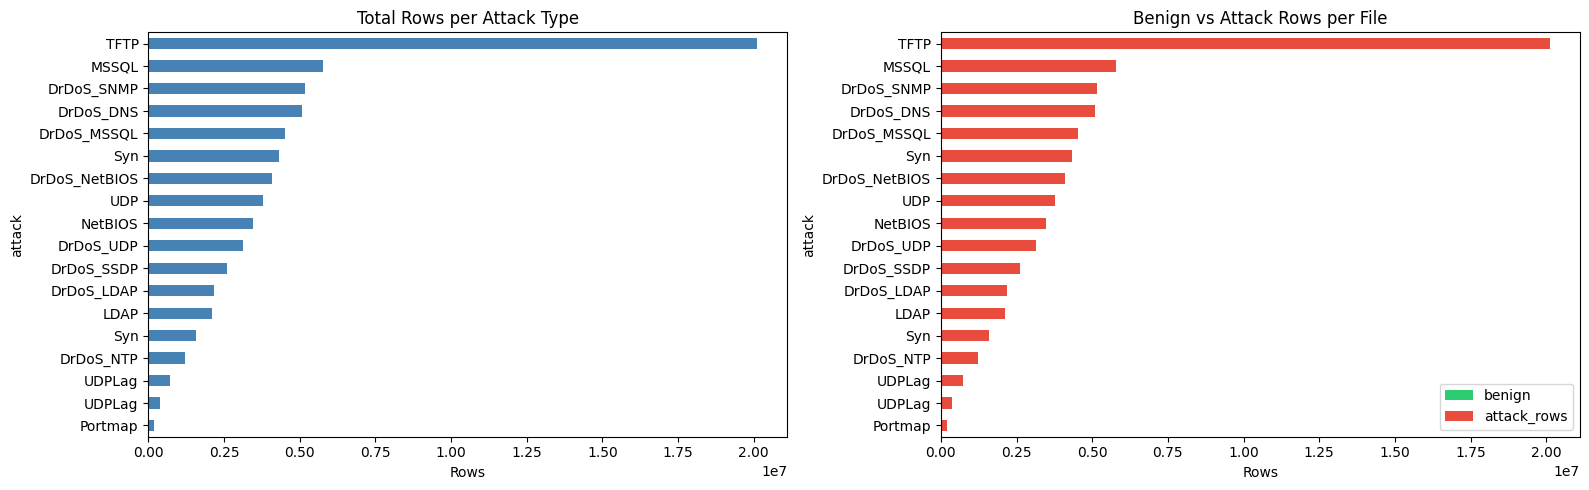

In [5]:

# ── 2.1 Per-file row / class distribution ──────────────────────
print("=== Dataset Summary ===")
print(summary_df.to_string(index=False))
print(f"\nTotal rows : {summary_df['rows'].sum():,}")
print(f"Total benign: {summary_df['benign'].sum():,}")
print(f"Total attack: {summary_df['attack_rows'].sum():,}")

# ── Bar chart: rows per attack type ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
summary_df.set_index("attack")["rows"].sort_values().plot(
    kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Total Rows per Attack Type")
axes[0].set_xlabel("Rows")

# Benign vs Attack per file
summary_df.set_index("attack")[["benign","attack_rows"]].sort_values("attack_rows").plot(
    kind="barh", ax=axes[1], stacked=True, color=["#2ecc71","#e74c3c"])
axes[1].set_title("Benign vs Attack Rows per File")
axes[1].set_xlabel("Rows")
plt.tight_layout()
plt.show()


Shape of EDA sample: (3521374, 88)

Data types:
 float32    45
int32      37
object      6
Name: count, dtype: int64

Missing values (top 20):
Flow Bytes/s      108130
Flow Packets/s    108130
dtype: int64

Class distribution in sample:
Label
TFTP             1004183
Syn               323794
MSSQL             289355
DrDoS_SNMP        257996
DrDoS_DNS         253555
DrDoS_MSSQL       226127
DrDoS_NetBIOS     204668
UDP               193301
NetBIOS           182888
DrDoS_UDP         156703
DrDoS_SSDP        130521
DrDoS_LDAP        109005
LDAP               95746
DrDoS_NTP          60133
UDP-lag            18324
Portmap             9350
BENIGN              5603
UDPLag                97
WebDDoS               25
Name: count, dtype: int64


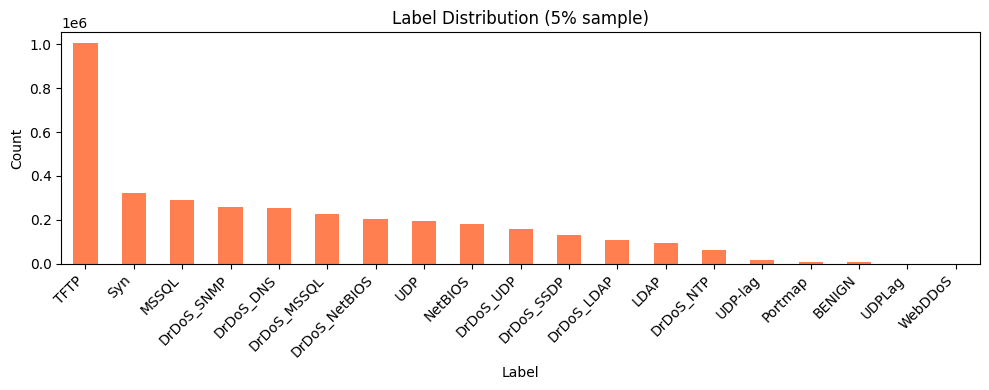

In [6]:

# ── 2.2 EDA sample: basic info ─────────────────────────────────
print("Shape of EDA sample:", eda_df.shape)
print("\nData types:\n", eda_df.dtypes.value_counts())
print("\nMissing values (top 20):")
missing = eda_df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False).head(20))

# ── Class distribution in sample ───────────────────────────────
if LABEL_COL in eda_df.columns:
    print("\nClass distribution in sample:")
    print(eda_df[LABEL_COL].value_counts())

    fig, ax = plt.subplots(figsize=(10, 4))
    eda_df[LABEL_COL].value_counts().plot(kind="bar", ax=ax, color="coral")
    ax.set_title("Label Distribution (5% sample)")
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [7]:

# ── 2.3 Descriptive statistics on numeric columns ──────────────
num_cols = eda_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric features: {len(num_cols)}")
eda_df[num_cols].describe().T.sort_values("std", ascending=False).head(20)


Numeric features: 82


,count,mean,std,min,25%,50%,75%,max
Flow Bytes/s,3413244.0,7.621258e+08,9.057279e+08,0.000000e+00,13414.804688,458000000.0,1.032000e+09,2.944000e+09
Fwd Header Length,3521374.0,-8.568969e+07,4.180556e+08,-2.125438e+09,0.000000,40.0,4.000000e+01,2.116387e+09
Fwd Header Length.1,3521374.0,-8.568969e+07,4.180556e+08,-2.125438e+09,0.000000,40.0,4.000000e+01,2.116387e+09
min_seg_size_forward,3521374.0,-4.415302e+07,2.120726e+08,-1.408238e+09,0.000000,14.0,2.000000e+01,6.724045e+07
Flow Duration,3521374.0,1.194353e+06,6.514878e+06,0.000000e+00,1.000000,1.0,1.200000e+02,1.200000e+08
Fwd IAT Total,3521374.0,1.193751e+06,6.513962e+06,0.000000e+00,1.000000,1.0,5.200000e+01,1.200000e+08
Bwd Header Length,3521374.0,-6.624814e+03,3.756614e+06,-2.125438e+09,0.000000,0.0,0.000000e+00,4.409205e+07
Bwd IAT Total,3521374.0,1.618309e+05,2.817647e+06,0.000000e+00,0.000000,0.0,0.000000e+00,1.199999e+08
Flow IAT Max,3521374.0,6.829701e+05,2.543668e+06,0.000000e+00,1.000000,1.0,1.040000e+02,1.199155e+08
Fwd IAT Max,3521374.0,6.826094e+05,2.542375e+06,0.000000e+00,1.000000,1.0,5.100000e+01,1.199155e+08


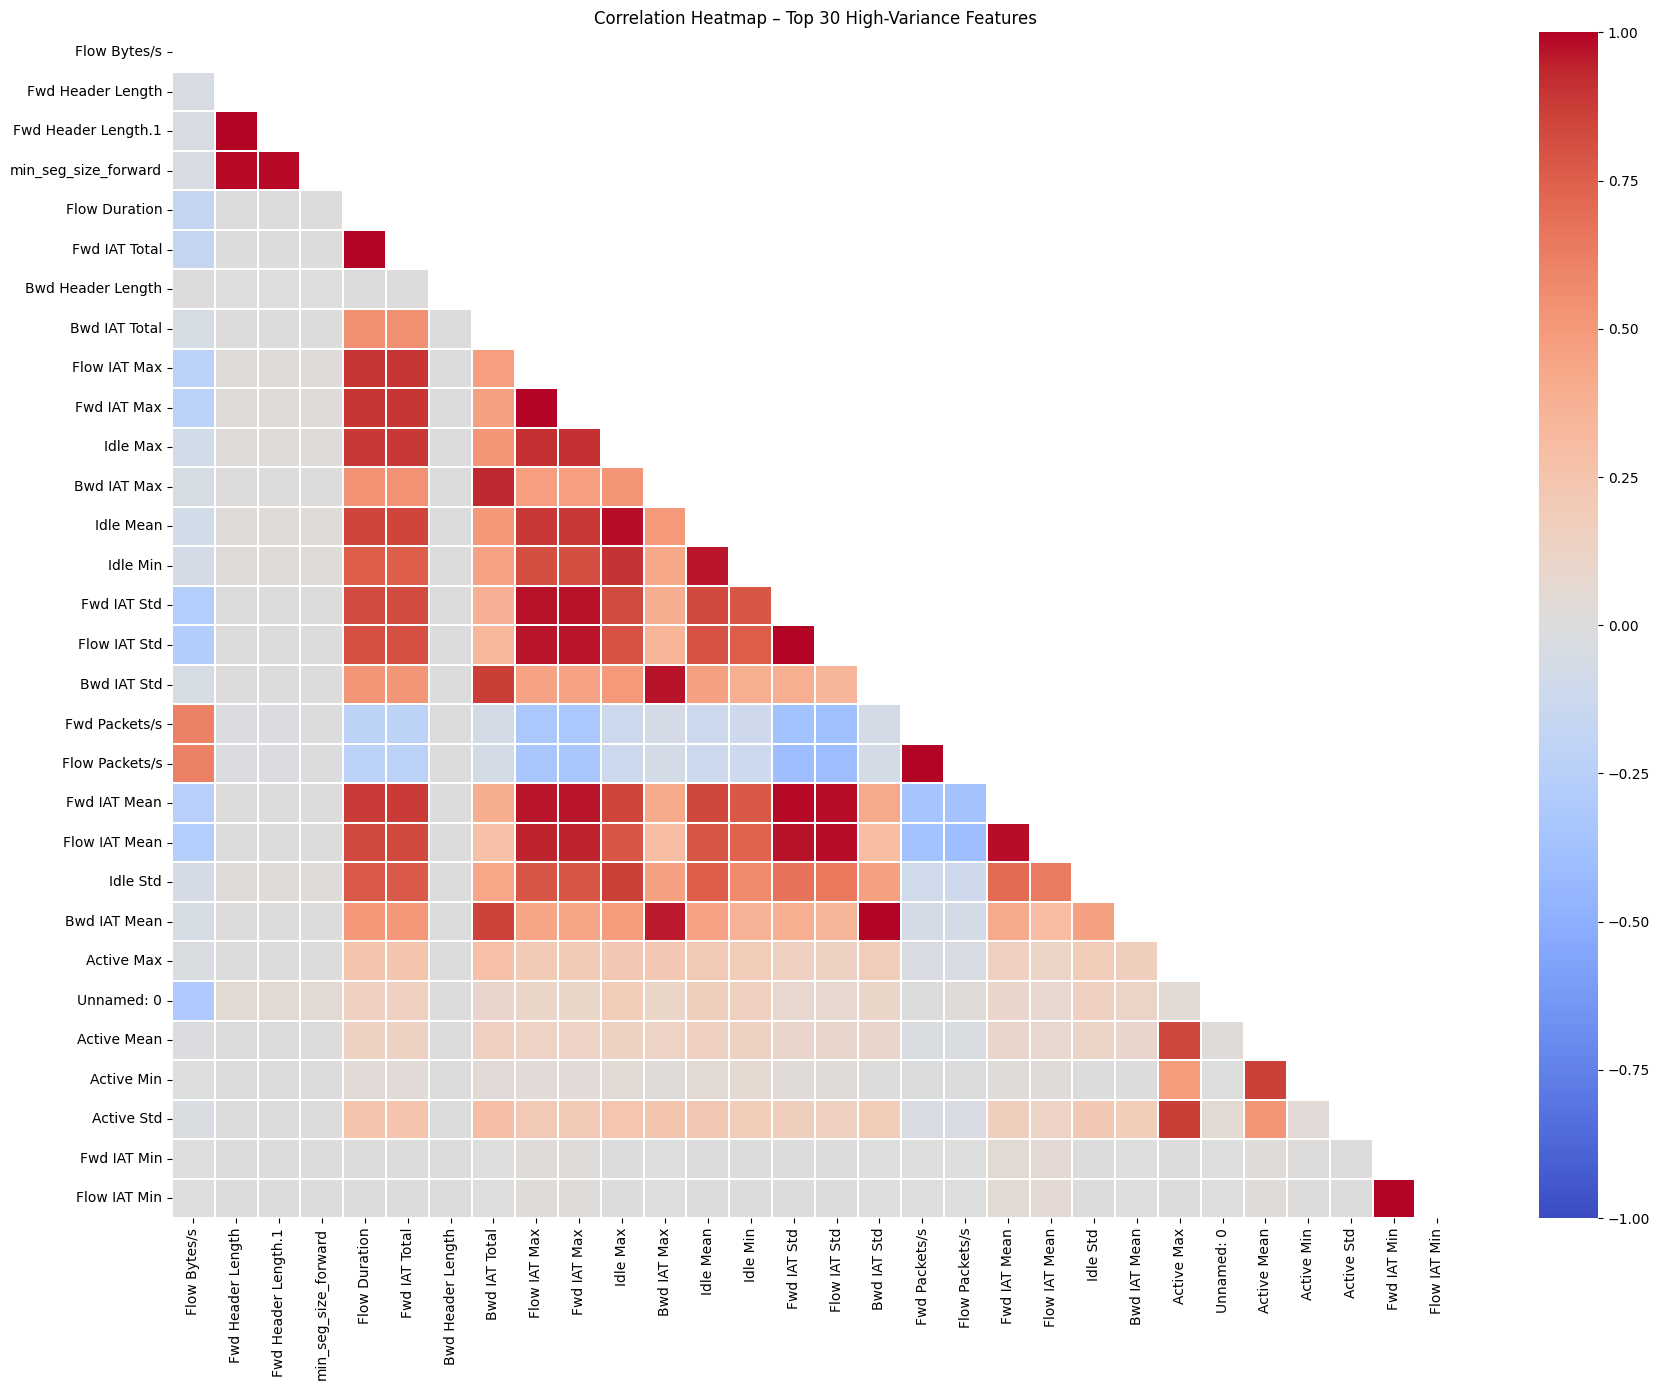

In [8]:

# ── 2.4 Correlation heatmap (top-30 most-varying features) ─────
top30 = (eda_df[num_cols]
         .std()
         .replace(0, np.nan)
         .dropna()
         .nlargest(30)
         .index.tolist())

corr = eda_df[top30].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            annot=False, linewidths=0.3, vmin=-1, vmax=1)
plt.title("Correlation Heatmap – Top 30 High-Variance Features")
plt.tight_layout()
plt.show()


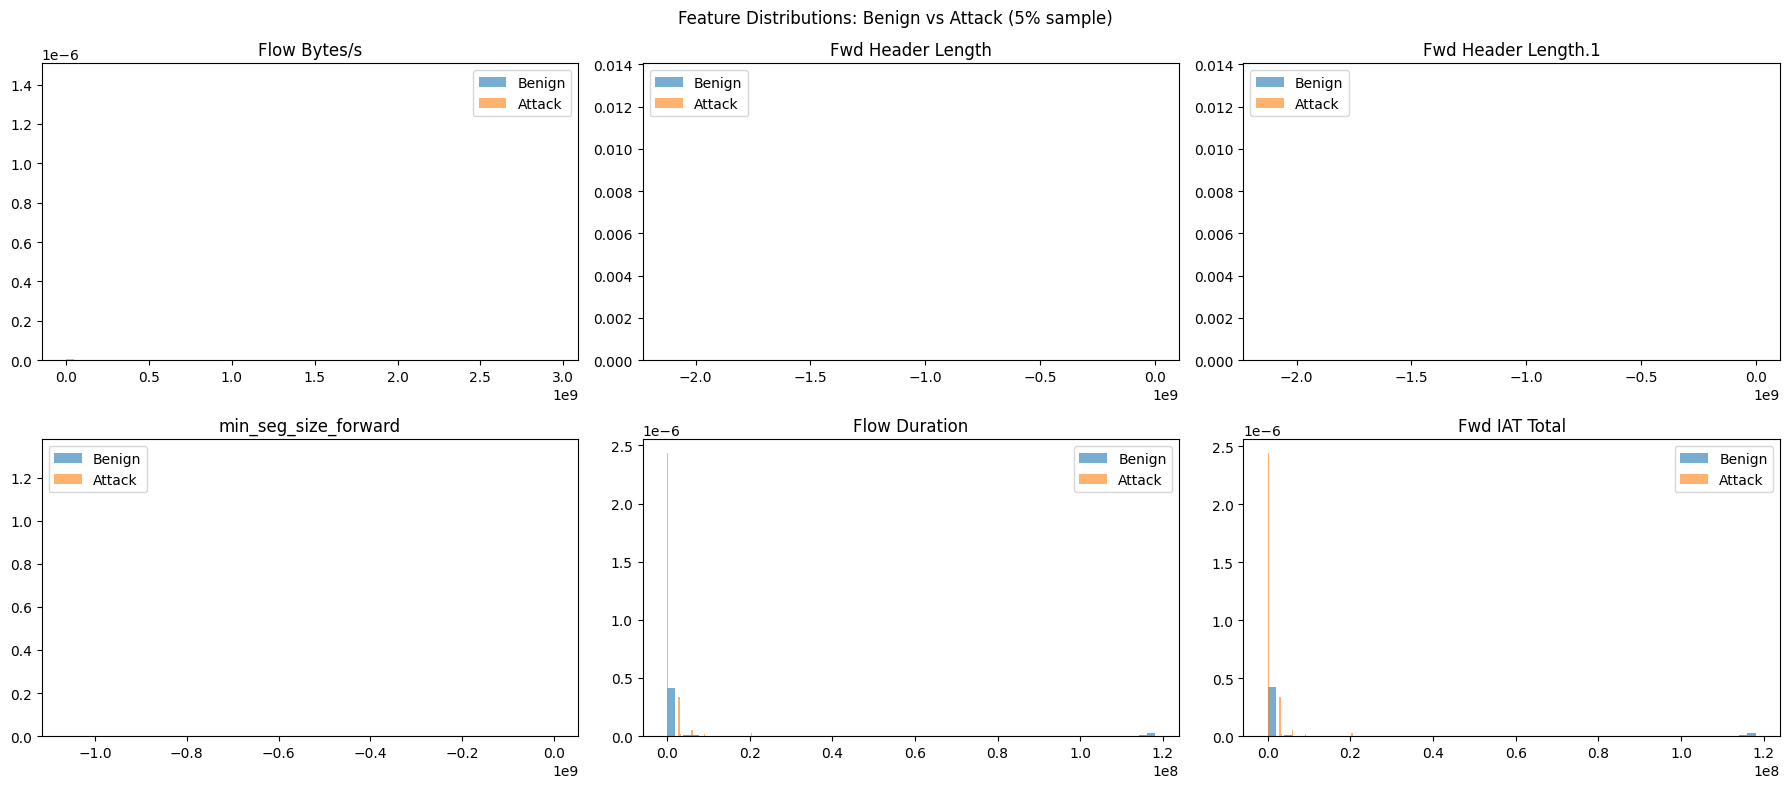

In [9]:

# ── 2.5 Feature distributions: benign vs attack (top-6 features) ─
if LABEL_COL in eda_df.columns:
    # binary label for plotting
    eda_df["is_attack"] = (eda_df[LABEL_COL] != "BENIGN").astype(int)

    top6 = (eda_df[num_cols]
            .std()
            .replace(0, np.nan)
            .dropna()
            .nlargest(6)
            .index.tolist())

    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    axes = axes.flatten()
    for i, col in enumerate(top6):
        for cls, grp in eda_df.groupby("is_attack")[col]:
            label = "Attack" if cls == 1 else "Benign"
            axes[i].hist(grp.dropna().clip(lower=grp.quantile(0.01),
                                            upper=grp.quantile(0.99)),
                         bins=60, alpha=0.6, label=label, density=True)
        axes[i].set_title(col[:40])
        axes[i].legend()
    plt.suptitle("Feature Distributions: Benign vs Attack (5% sample)")
    plt.tight_layout()
    plt.show()


## 3. Preprocessing
Steps:
1. Drop constant / duplicate columns
2. Handle NaN and Inf
3. Encode labels (binary **or** multi-class)
4. Remove highly correlated features (>0.98)
5. StandardScaler


In [10]:

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold

# ── Work on the EDA sample (fast dev loop) ─────────────────────
df = eda_df.copy()

# 3.1 Drop columns that are not useful ─────────────────────────
COLS_TO_DROP = ["Flow ID", "Source IP", "Destination IP",
                "Source Port", "Destination Port", "Timestamp",
                "is_attack"]   # derived helper
df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns],
        inplace=True, errors="ignore")

# 3.2 Replace Inf / NaN ─────────────────────────────────────────
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# 3.3 Encode label ──────────────────────────────────────────────
# BINARY:  0 = BENIGN, 1 = ATTACK
# MULTI:   each attack type gets its own integer
binary = True   # set False for multi-class

le = LabelEncoder()
if LABEL_COL in df.columns:
    if binary:
        df["target"] = (df[LABEL_COL] != "BENIGN").astype(int)
    else:
        df["target"] = le.fit_transform(df[LABEL_COL])
        print("Classes:", dict(enumerate(le.classes_)))
    df.drop(columns=[LABEL_COL], inplace=True)

# 3.4 Remove zero-variance features ────────────────────────────
feat_cols = df.select_dtypes(include=[np.number]).columns.drop("target", errors="ignore")
vt = VarianceThreshold(threshold=0.0)
vt.fit(df[feat_cols])
low_var = feat_cols[~vt.get_support()].tolist()
print(f"Dropping {len(low_var)} zero-variance columns: {low_var[:10]}")
df.drop(columns=low_var, inplace=True, errors="ignore")

# 3.5 Remove highly correlated features (|r| > 0.98) ──────────
feat_cols = df.select_dtypes(include=[np.number]).columns.drop("target", errors="ignore")
corr_mat = df[feat_cols].corr().abs()
upper     = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
to_drop   = [c for c in upper.columns if any(upper[c] > 0.98)]
print(f"Dropping {len(to_drop)} highly-correlated features")
df.drop(columns=to_drop, inplace=True, errors="ignore")

feat_cols = [c for c in df.columns if c != "target"]
print(f"\nFinal feature count: {len(feat_cols)}")
print(f"Class balance:\n{df['target'].value_counts()}")


Dropping 12 zero-variance columns: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count', 'PSH Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk']
Dropping 23 highly-correlated features

Final feature count: 46
Class balance:
target
1    3515771
0       5603
Name: count, dtype: int64


## 4. Train / Evaluate on the Sample
For production training on full 30 GB see **Section 5** (chunked incremental learning).


In [ ]:

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing  import StandardScaler
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.linear_model    import LogisticRegression, SGDClassifier
from sklearn.metrics         import (classification_report, confusion_matrix,
                                     roc_auc_score, f1_score)
import lightgbm as lgb          # pip install lightgbm
import joblib

# ── Train / test split ─────────────────────────────────────────
X = df[feat_cols].values.astype("float32")
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ── Models to benchmark ────────────────────────────────────────
models = {
    "Decision Tree"     : DecisionTreeClassifier(max_depth=15, random_state=42),
    "Random Forest"     : RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                                  random_state=42),
    "LightGBM"          : lgb.LGBMClassifier(n_estimators=200, n_jobs=-1,
                                               random_state=42, verbose=-1),
    "SGD (linear)"      : SGDClassifier(loss="modified_huber", max_iter=100,
                                         n_jobs=-1, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1     = f1_score(y_test, y_pred, average="weighted")
    try:
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    except Exception:
        auc = float("nan")
    results[name] = {"F1": f1, "AUC": auc}
    print(f"\n{'─'*50}\n{name}")
    print(classification_report(y_test, y_pred,
                                 target_names=["Benign","Attack"] if binary
                                 else [str(c) for c in le.classes_]))

results_df = pd.DataFrame(results).T
print("\n=== Summary ===")
print(results_df.sort_values("F1", ascending=False))


In [ ]:

# ── 4.1 Feature Importance (Random Forest) ─────────────────────
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
importances.head(20).plot(kind="bar", color="royalblue")
plt.title("Top 20 Feature Importances – Random Forest")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

TOP_N_FEATURES = 30
selected_features = importances.head(TOP_N_FEATURES).index.tolist()
print(f"Selected top {TOP_N_FEATURES} features for full training:")
print(selected_features)


In [ ]:

# ── 4.2 Confusion Matrix for best model ────────────────────────
best_name = results_df["F1"].idxmax()
best_model = models[best_name]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign","Attack"] if binary else le.classes_,
            yticklabels=["Benign","Attack"] if binary else le.classes_)
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


## 5. Full-Data Training on 30 GB — Incremental Learning
Two options for fitting a model on the whole dataset without loading it into RAM:

| Option | Algorithm | API |
|--------|-----------|-----|
| A | SGDClassifier / PassiveAggressive | `partial_fit()` loop over chunks |
| B | LightGBM | `lgb.train()` with `init_model` continued per file |

**Option A** (SGD) is shown below — simplest & lowest RAM.  
Swap `SGDClassifier` for `lgb.LGBMClassifier` in the LightGBM option.


In [ ]:

from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import joblib

# ── Re-use the features selected from the RF importance step ───
# selected_features must be defined (run Section 4.1 first)
CLASSES = [0, 1]   # binary

# ── Online scaler + model ──────────────────────────────────────
online_scaler = StandardScaler()
online_model  = SGDClassifier(
    loss="modified_huber",   # gives predict_proba
    class_weight="balanced", # handles imbalance automatically
    max_iter=1,
    tol=None,
    random_state=42,
    n_jobs=-1,
)

chunk_count  = 0
COLS_TO_DROP_FULL = ["Flow ID", "Source IP", "Destination IP",
                     "Source Port", "Destination Port", "Timestamp"]

for csv_path in all_csv:
    reader = pd.read_csv(csv_path, chunksize=CHUNK_SIZE,
                         low_memory=False, on_bad_lines="skip")
    for chunk in reader:
        chunk.columns = chunk.columns.str.strip()
        chunk = reduce_mem(chunk)
        chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
        chunk.drop(columns=[c for c in COLS_TO_DROP_FULL if c in chunk.columns],
                   inplace=True, errors="ignore")

        if LABEL_COL not in chunk.columns:
            continue

        # keep only selected features that exist in this chunk
        avail_feats = [f for f in selected_features if f in chunk.columns]
        chunk.fillna(chunk.median(numeric_only=True), inplace=True)

        X_chunk = chunk[avail_feats].values.astype("float32")
        y_chunk = (chunk[LABEL_COL] != "BENIGN").astype(int).values

        # incremental scaling: partial_fit
        online_scaler.partial_fit(X_chunk)
        X_scaled = online_scaler.transform(X_chunk)

        online_model.partial_fit(X_scaled, y_chunk, classes=CLASSES)

        chunk_count += 1
        if chunk_count % 20 == 0:
            print(f"  Trained on {chunk_count} chunks so far …")

        del chunk, X_chunk, X_scaled
        gc.collect()

print(f"\nDone. Total chunks processed: {chunk_count}")

# ── Save the final model ───────────────────────────────────────
joblib.dump(online_model,  "ddos_sgd_model.pkl")
joblib.dump(online_scaler, "ddos_scaler.pkl")
print("Model saved: ddos_sgd_model.pkl")


## 5B. Full-Data Training — LightGBM (continued training per file)
LightGBM supports **`init_model`** which lets you continue boosting on each new file.  
Each file adds `N_ROUNDS` more trees to the existing forest.


In [ ]:

import lightgbm as lgb

N_ROUNDS    = 50    # trees added per file iteration
LGB_PARAMS  = {
    "objective"       : "binary",
    "metric"          : "auc",
    "learning_rate"   : 0.05,
    "num_leaves"      : 63,
    "min_child_samples": 50,
    "subsample"       : 0.8,
    "colsample_bytree": 0.8,
    "class_weight"    : "balanced",
    "n_jobs"          : -1,
    "verbose"         : -1,
}

lgb_model_path = None   # will hold path to saved model

for file_idx, csv_path in enumerate(all_csv):
    # load entire file in chunks → concat (fits if each file < 3 GB)
    file_chunks = []
    for chunk in pd.read_csv(csv_path, chunksize=CHUNK_SIZE,
                              low_memory=False, on_bad_lines="skip"):
        chunk.columns = chunk.columns.str.strip()
        chunk = reduce_mem(chunk)
        chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
        chunk.drop(columns=[c for c in COLS_TO_DROP_FULL if c in chunk.columns],
                   inplace=True, errors="ignore")
        avail = [f for f in selected_features if f in chunk.columns]
        chunk.fillna(chunk.median(numeric_only=True), inplace=True)
        file_chunks.append(chunk[avail + [LABEL_COL]])

    file_df = pd.concat(file_chunks, ignore_index=True)
    del file_chunks; gc.collect()

    avail = [f for f in selected_features if f in file_df.columns]
    X_file = file_df[avail].values.astype("float32")
    y_file = (file_df[LABEL_COL] != "BENIGN").astype(int).values
    del file_df; gc.collect()

    dtrain = lgb.Dataset(X_file, label=y_file, free_raw_data=True)
    del X_file, y_file; gc.collect()

    lgb_model_path = f"ddos_lgb_checkpoint.txt"
    lgb.train(
        LGB_PARAMS,
        dtrain,
        num_boost_round=N_ROUNDS,
        init_model=lgb_model_path if file_idx > 0 else None,
        keep_training_booster=False,
    ).save_model(lgb_model_path)

    print(f"  [{file_idx+1}/{len(all_csv)}] Trained on {csv_path.name}")

print(f"\nLightGBM model saved to {lgb_model_path}")


## 6. Final Evaluation on Held-Out Test Set
We evaluate the trained LightGBM on the 5% EDA sample (unseen data from above).


In [ ]:

from sklearn.metrics import roc_curve, auc as sklearn_auc

# Load saved LightGBM model
final_lgb = lgb.Booster(model_file="ddos_lgb_checkpoint.txt")

avail = [f for f in selected_features if f in df.columns]
X_eval = df[avail].values.astype("float32")
y_eval = df["target"].values

y_prob = final_lgb.predict(X_eval)
y_pred = (y_prob >= 0.5).astype(int)

print("=== LightGBM — Final Evaluation ===")
print(classification_report(y_eval, y_pred,
                             target_names=["Benign","Attack"]))
print(f"ROC-AUC: {roc_auc_score(y_eval, y_prob):.4f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_eval, y_prob)
roc_auc     = sklearn_auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — LightGBM DDoS Detection")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 7. Tips & Best Practices for 30 GB CIC-DDoS 2019

### Memory Management
| Technique | Why |
|-----------|-----|
| `chunksize` in `read_csv` | Never load a full file |
| `float32` instead of `float64` | Halves RAM per numeric column |
| `gc.collect()` after each chunk | Returns memory immediately |
| Drop metadata columns early | IP, Port, Timestamp add no ML signal |

### Class Imbalance
CIC-DDoS 2019 is **heavily imbalanced** (benign << attack in most files).  
Mitigations: `class_weight="balanced"`, SMOTE on sample, or threshold tuning.

### Feature Engineering Ideas
- Packet-rate features: `Tot Fwd Pkts / Flow Duration`
- Byte-rate: `TotLen Fwd Pkts / Flow Duration`
- Flag ratios: `SYN Flag Cnt / Tot Fwd Pkts`

### Scaling to Production
- Use **Dask** or **Polars** for distributed EDA
- Convert CSVs to **Parquet** once (`df.to_parquet(...)`) for 5-10× faster reads
- Use **LightGBM checkpointing** (Section 5B) for full-data training
- Serialize with `joblib`: model + scaler + feature list

### Parquet Conversion (one-time, recommended)
```python
for csv_path in all_csv:
    parquet_path = csv_path.with_suffix(".parquet")
    pd.read_csv(csv_path, low_memory=False).to_parquet(parquet_path, index=False)
```
